   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1               6.0    1.0  
2               3.0    1.0  
3              29.0    1.0  
4              20.0    1.

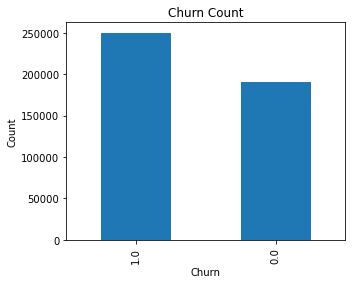

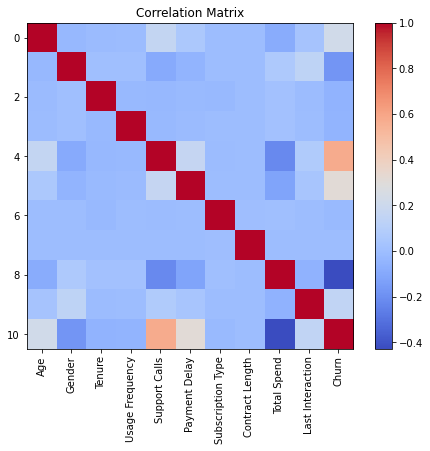

Scaled Features:
[[-7.53326296e-01 -1.14590897e+00  4.48759584e-01 -2.10510685e-01
   4.54549165e-01  6.09620485e-01  1.21154605e+00 -1.11466372e+00
   1.24742680e+00  2.93051885e-01]
 [ 2.05964592e+00 -1.14590897e+00  1.02827797e+00 -1.72456250e+00
   2.08309993e+00 -6.01318682e-01 -1.24555729e+00  1.69163167e-03
  -3.09864524e-01 -9.86583611e-01]
 [ 1.25593957e+00 -1.14590897e+00 -1.00003639e+00 -1.37516593e+00
   7.80259318e-01  6.09620485e-01 -1.24555729e+00  1.11804698e+00
  -1.85469752e+00 -1.33557511e+00]
 [ 1.49705148e+00  8.72669671e-01  3.90807745e-01  6.04747985e-01
   1.10596947e+00 -7.22412599e-01  1.21154605e+00  1.69163167e-03
  -9.78461601e-01  1.68901788e+00]
 [-1.31592074e+00  8.72669671e-01  4.30967110e-02  4.88282461e-01
   4.54549165e-01 -6.01318682e-01 -1.24555729e+00  1.69163167e-03
  -6.06979119e-02  6.42043383e-01]]
Training Samples: 352665
Testing Samples: 88167
Training Completed Successfully.
Predicted Values:
[1. 1. 0. ... 0. 1. 0.]

Accuracy= 0.85045425159

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression 

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
#Load the Dataset
df=pd.read_csv(r"C:\Users\user\Downloads\customer_churn_dataset-training-master.csv")  

print(df.head())
#Understand the Data
print("Shape Of Dataset")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nInformation")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing values")
print(df.isnull().sum())
#Data Preprocessing
df.drop("CustomerID",axis=1,inplace=True)
df=df.dropna(subset=['Churn'])
nums_cols=["Age","Tenure","Usage Frequency","Support Calls","Payment Delay","Total Spend","Last Interaction"]
for col in nums_cols:
    df[col].fillna(df[col].median(),inplace=True)
cat_cols=["Gender","Subscription Type","Contract Length"]
for col in cat_cols:
    df[col].fillna(df[col].mode()[0],inplace=True)
print(df.head())
print(df.isnull().sum())
#CATEGORIAL DATA
print("\n=============LABEL ENCODING==============\n")
encoder=LabelEncoder()
df['Gender']=encoder.fit_transform(df['Gender'])
df['Subscription Type']=encoder.fit_transform(df['Subscription Type'])
df['Contract Length']=encoder.fit_transform(df['Contract Length'])


print(df.head())
#EXPLORATORY DATA ANALYSIS 

print("\n================EDA==================\n")
print(df['Churn'].value_counts())
#Churn Count
plt.figure(figsize=(5,4))
df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Count")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()
# Correlation Matrix
plt.figure(figsize=(8,6))
plt.imshow(df.corr(),cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(df.columns)),df.columns,rotation=90)
plt.xticks(range(len(df.columns)),df.columns)

plt.title("Correlation Matrix")
plt.show()
#SCALING

X=df.drop("Churn",axis=1)
y=df["Churn"]

scaler=StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Features:")
print(X_scaled[:5])
#SPLIT THE DATA
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.20,random_state=42)

print("Training Samples:",len(X_train))
print("Testing Samples:",len(X_test))

#CHOOSE THE MODEL

model=LogisticRegression()

#TRAIN THE MODEL

model.fit(X_train,y_train)
print("Training Completed Successfully.")
#TEST THE MODEL

y_pred=model.predict(X_test)
print("Predicted Values:")
print(y_pred)
#EVALUATE THE MODEL

accuracy=accuracy_score(y_test,y_pred)
print("\nAccuracy=",accuracy)

print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred))


print("\nClassification Report")
print(classification_report(y_test,y_pred))
#PREDICT NEW CUSTOMER

# Features :age,gender,tenure,Usage Frequency,support calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction

new_customer = [[
    24,     # Age
    1,      # Gender (1 = Male)
    3,      # Tenure (months)
    2,      # Usage Frequency
    8,      # Support Calls
    15,     # Payment Delay (days)
    0,      # Subscription Type (Basic)
    0,      # Contract Length (Monthly)
    180.50, # Total Spend
    5       # Last Interaction (days ago)
]]
                
new_scaled=scaler.transform(new_customer)
   
prediction = model.predict(new_scaled)
                
if prediction[0]==1:   
    print("CUSTOMER WILL CHURN")
else:
    print("CUSTOMER WILL NOT CHURN")
    
accuracy=accuracy_score(y_test,y_pred)
print("\nAccuracy=",accuracy)
                
print("\n============MACHINE LEARNING PIPELINE COMPLETED===============\n")





 
